``AAPredPlot().predict(data, kind=...)`` is the single entry point for sample-prediction figures: ``kind`` selects the renderer and ``data`` is its input. We first fit an ``AAPred`` and generate the predictions to visualize (see [Breimann25]_):

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import aaanalysis as aa
aa.options["verbose"] = False  # Disable verbosity
aa.plot_settings()

# DOM_GSEC example dataset + its feature set (see [Breimann25]_)
df_seq = aa.load_dataset(name="DOM_GSEC")
labels = df_seq["label"].to_list()
df_feat = aa.load_features(name="DOM_GSEC").head(20)

sf = aa.SequenceFeature()
X = sf.feature_matrix(features=df_feat, df_parts=sf.get_df_parts(df_seq=df_seq))
aapred = aa.AAPred(df_feat=df_feat, random_state=42).fit(X, labels)
aapred_plot = aa.AAPredPlot()

# Per-residue and per-domain predictions for one protein (APP, P05067)
one = df_seq[df_seq["entry"] == "P05067"]
df_window = aapred.predict(one[["entry", "sequence"]], level="window", tmd_len=15, step=5)
df_domain = aapred.predict(one, level="domain", window=5)

# Per-protein scores for the cohort plots
scores = aapred.predict(df_seq, level="seq")["score"].to_numpy()

**Positional profiles.** ``kind='window'`` draws the per-residue profile with an optional decision ``threshold``, annotation tracks (``list_annotations``), a line ``color`` and axis labels; ``entry`` selects the protein when ``data`` holds several:

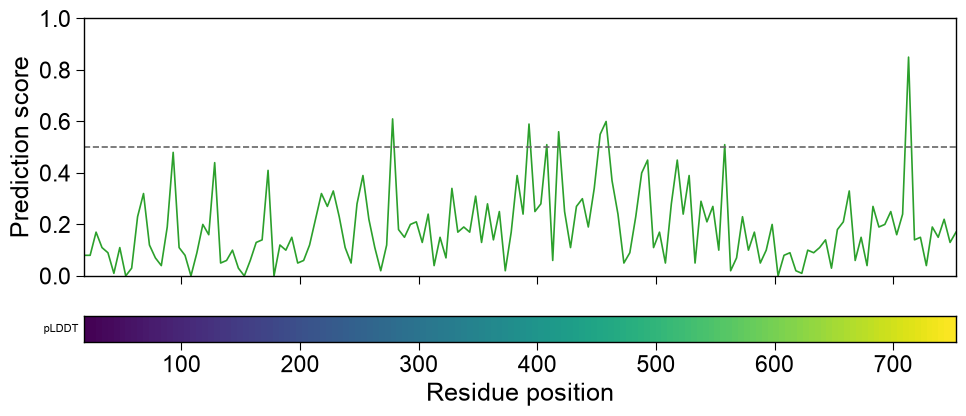

In [2]:
n_pos = len(df_window)
list_annotations = [{"values": np.linspace(0, 1, n_pos), "label": "pLDDT", "cmap": "viridis"}]
aapred_plot.predict(df_window, kind="window", entry="P05067", threshold=0.5,
                    list_annotations=list_annotations, color="tab:green", figsize=(10, 4.5),
                    xlabel="Residue position", ylabel="Prediction score")
plt.tight_layout()
plt.show()

``kind='domain'`` shows how the score depends on the exact boundary; the best offset is starred:

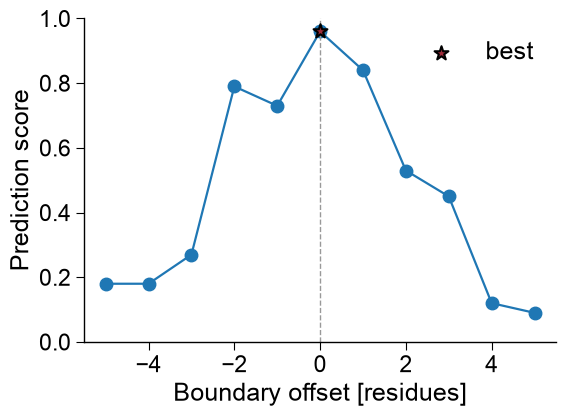

In [3]:
aapred_plot.predict(df_domain, kind="domain", entry="P05067", color="tab:blue",
                    figsize=(6, 4.5), xlabel="Boundary offset [residues]",
                    ylabel="Prediction score")
plt.tight_layout()
plt.show()

**Score cohorts.** ``kind='hist'`` separates the score distribution by class (``labels``), with ``bins``, decision ``thresholds`` and a per-class ``dict_color``:

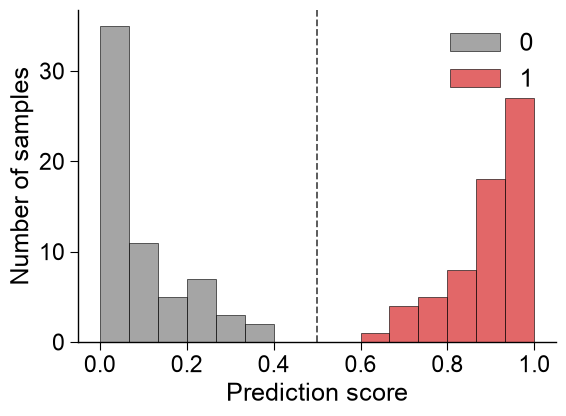

In [4]:
aapred_plot.predict(scores, kind="hist", labels=labels, bins=15, thresholds=[0.5],
                    dict_color={1: "tab:red", 0: "tab:gray"},
                    xlabel="Prediction score", ylabel="Number of samples")
plt.tight_layout()
plt.show()

``kind='cutoff'`` is the survival curve — the percentage of samples scoring at or above each cutoff (``n_steps`` controls the resolution):

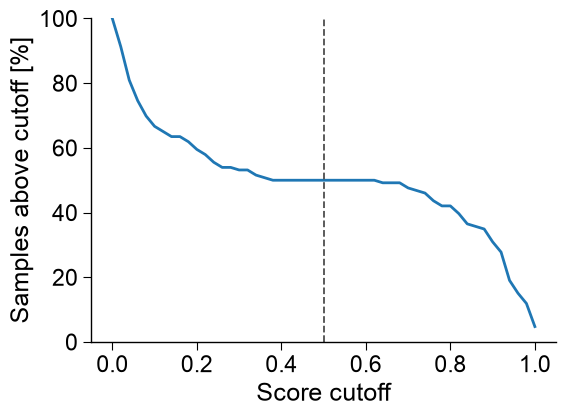

In [5]:
aapred_plot.predict(scores, kind="cutoff", n_steps=51, color="tab:blue", thresholds=[0.5],
                    xlabel="Score cutoff", ylabel="Samples above cutoff [%]")
plt.tight_layout()
plt.show()

``kind='scatter'`` compares two predictors per sample; ``data`` is the x-axis and the required ``scores_y`` is the y-axis, with the ``y = x`` ``diagonal``, ``marker_size`` and ``dict_color``:

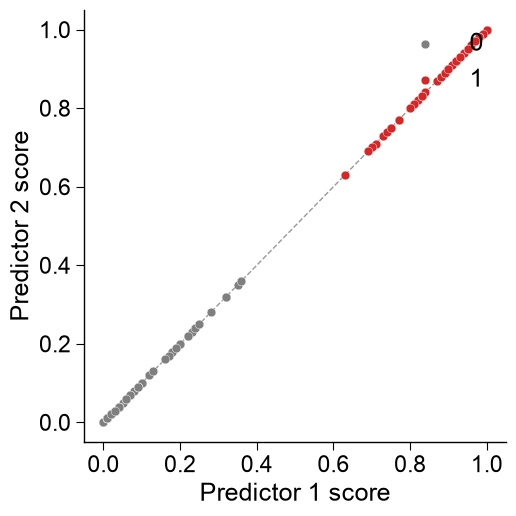

In [6]:
scores_y = aapred.predict(df_seq, level="seq",
                          list_parts=["tmd", "jmd_n_tmd_n", "tmd_c_jmd_c"])["score"].to_numpy()
aapred_plot.predict(scores, kind="scatter", scores_y=scores_y, labels=labels,
                    dict_color={1: "tab:red", 0: "tab:gray"}, marker_size=40, diagonal=True,
                    xlabel="Predictor 1 score", ylabel="Predictor 2 score")
plt.tight_layout()
plt.show()

**Ranked candidates.** ``kind='ranking'`` ranks samples as horizontal bars colored by class, reading columns by name (``col_name``, ``col_score``, ``col_group``, ``col_std``) with ``colors``, confidence ``cutoffs``, ``top_n`` and ``ascending`` order:

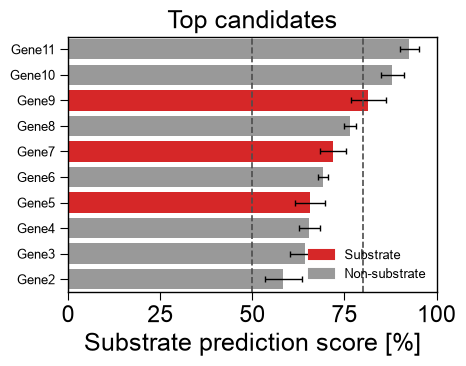

In [7]:
rng = np.random.RandomState(0)
df_rank = pd.DataFrame({
    "name":  [f"Gene{i}" for i in range(12)],
    "score": np.sort(rng.uniform(30, 95, 12)),
    "group": rng.choice(["Substrate", "Non-substrate"], 12),
    "std":   rng.uniform(1, 5, 12),
})
aapred_plot.predict(df_rank, kind="ranking", col_name="name", col_score="score",
                    col_group="group", col_std="std",
                    colors={"Substrate": "tab:red", "Non-substrate": "0.6"},
                    cutoffs=(50, 80), top_n=10, ascending=False, figsize=(5, 4),
                    xlabel="Substrate prediction score [%]", title="Top candidates")
plt.tight_layout()
plt.show()

**Explanation similarity.** ``kind='clustermap'`` clusters samples by *why* the model scores them — the correlation of their per-sample importance vectors — with ``names``, class ``labels`` / ``colors``, ``cmap``, ``cbar_label`` and ``title`` (``data`` is the importance matrix; the clustermap owns its figure, so ``ax`` is ignored):

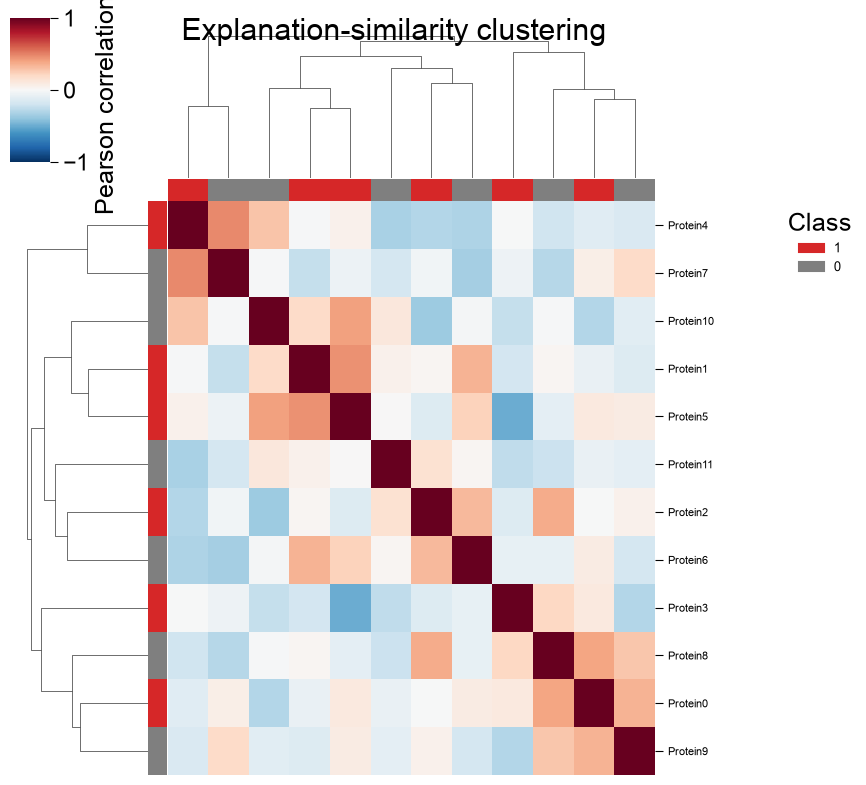

In [8]:
block_a = rng.normal(0.6, 0.2, size=(6, 20))
block_b = rng.normal(-0.6, 0.2, size=(6, 20))
data = np.vstack([block_a, block_b])
imp_labels = np.array([1] * 6 + [0] * 6)
names = [f"Protein{i}" for i in range(12)]
aapred_plot.predict(data, kind="clustermap", names=names, labels=imp_labels,
                    colors={1: "tab:red", 0: "tab:gray"}, cmap="RdBu_r", figsize=(8, 8),
                    cbar_label="Pearson correlation (r)",
                    title="Explanation-similarity clustering")
plt.show()